# E02 Time series - solutions

1. Download the numpy binary file `time-seriesE2.npy` located in the `excercises` folder of the [github repository](https://github.com/mgraupe/NeuralDataSciPy2026/tree/main/exercises) or the moodle. The data contained in the file represents a time-series. Load the file using the numpy `load` function and save the imported data in variable named `data` (note that the `time-seriesE2.npy` file needs to be located in the same folder as the jupyter-notebook).

In [4]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

data = np.load('time-seriesE2.npy')


2. Check the structure of the data and plot it in a meaningful way.

In [8]:
print(np.shape(data))
print(data[0])
print(data[:,0])
print(data[:,1])

(32500, 2)
[ 0.         -0.06418976]
[0.00000e+00 4.00000e-05 8.00000e-05 ... 1.29988e+00 1.29992e+00
 1.29996e+00]
[-0.06418976 -0.06400215 -0.06412722 ... -0.06065651 -0.06031256
 -0.06009369]


Text(0, 0.5, 'transmembrane voltage (mV)')

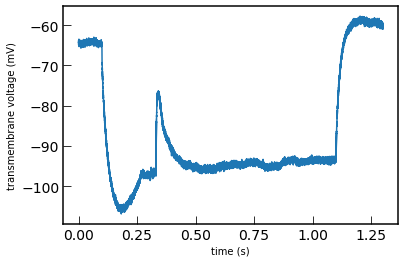

In [9]:
plt.plot(data[:,0],data[:,1]*1000.)
plt.xlabel('time (s)')
plt.ylabel('transmembrane voltage (mV)')

3. What is the time interval between each individual potential recording ? Is the interval the same throughout the recording, i.e., across all time points?  Compute the sampling frequency (or acquisition rate) of the data. 

In [12]:
intervals = np.diff(data[:,0])
print('first 100 and last 100 elements : ',intervals[:100],intervals[-100:])
print('The interval between recorings is : ', intervals[0]*1000, ' ms')
print('The sampling frequency of the data is : ', np.round(1/intervals[0],0), ' Hz')

first 100 and last 100 elements :  [4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05
 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05
 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05
 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05
 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05
 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05
 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05
 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05
 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05
 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05] [4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05
 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05
 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05
 4.e-05 4.e-05 4.e-05 4.e-05 4.e-05 4.e-0

Another way of verying the distribution of intervals -> plot the histogram. 

(array([    0.,     0.,     0., 13985., 18514.,     0.,     0.,     0.,
            0.,     0.]),
 array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ]),
 <BarContainer object of 10 artists>)

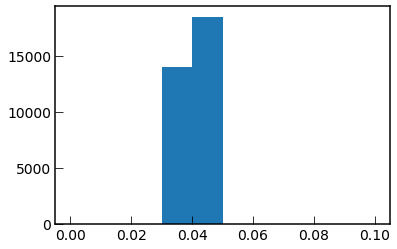

In [29]:
plt.hist(intervals*1000,range=[0,0.1])

Apart from numerical inaccuracies, the interval is constant throughout the recording. 

4. Calculate the mean of the first 500 data-points, and the mean of all data-points betweeen the 23,000th and 25,000th element. <br>**Hint:** You can use numpy slicing to access subsets of the array.

In [23]:
print('the mean of the first 500 data-points is :',np.mean(data[:500,1])*1000., 'mV')
print('the mean of all points betweeen the 23,000th and 25,000th element is :', np.mean(data[22999:25000,1])*1000,' mV')

the mean of the first 500 data-points is : -64.51112746755035 mV
the mean of all points betweeen the 23,000th and 25,000th element is : -93.76587758696688  mV


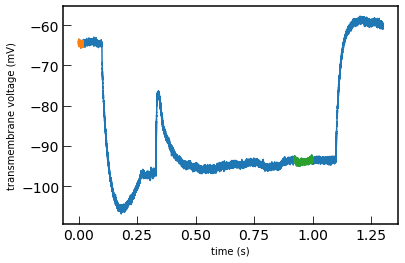

In [25]:
plt.plot(data[:,0],data[:,1]*1000.)
plt.xlabel('time (s)')
plt.ylabel('transmembrane voltage (mV)')
plt.plot(data[:500,0],data[:500,1]*1000.)
plt.plot(data[22999:25000,0],data[22999:25000,1]*1000.)

### The information below is not part of the homework assignment

Remember Ohm's law : R = U/I . In this experiment, a hyperpolarizing current has been injected. The input resistance of the neuron can be calcualted from the measured change in membrane potential. The injected current was I = -0.1 nA. In turn, the input resistance is : 

In [26]:
meanBeginning = np.mean(data[:500,1])
meanEnd = np.mean(data[22999:25000,1])
current = -0.1E-9
R = (meanEnd-(meanBeginning))/(current) # R = Delta U / I

In [27]:
print('The input resistance of the neuron is : ',R/1E6, 'MOhm')

The input resistance of the neuron is :  292.5475011941653 MOhm
